<a href="https://colab.research.google.com/github/artistvictorya/My-CS50-solutions/blob/main/Warsztaty_bioinformatyka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Konwersja z tiffa do chmury punktów

Rozpoczynamy od instalacji biblioteki gudhi do obliczeń topologicznych

In [ ]:
!pip install gudhi

Importujemy wszystkie niezbędne dla nas biblioteki

In [ ]:
import sys
import os
import argparse
import numpy as np
import gudhi
import matplotlib.pyplot as plt
import itertools
import sys
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

from tqdm import tqdm

Z każdego tifa w folderze images będziemy chcieli skonstruować png, a następnie przerobić go na chmurę punktów

Na początku podajemy argumenty - ścieżki do plików, które chcemy przerobić, threshold i miejsce w którym mają zostać zapisane wyniki.

In [ ]:
import sys
sys.argv = [
    'colab_kernel_launcher.py',
    '/content/images/0.tiff',
    '/content/images/1.tiff',
    '/content/images/2.tiff',
    '/content/images/3.tiff',
    '/content/images/4.tiff',
    '/content/images/5.tiff',
    '--threshold', '200',
    '--out-dir', '/content/results'
]


In [ ]:
def convert_to_png(image_path):
    if image_path.lower().endswith(".png"):
        return image_path

    png_path = os.path.splitext(image_path)[0] + ".png"
    print(f"[INFO] Konwersja {image_path} do {png_path}")

    with Image.open(image_path) as img:
        img.convert("L").save(png_path)

    return png_path

def image_to_point_cloud(image_path, threshold=None, tile_size=1000):
    with Image.open(image_path) as img:
        w, h = img.size
        print(f"[DEBUG] image size: {w} x {h}, mode: {img.mode}")

        points = []

        # Przetwarzanie kafelkami
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                # Wyznaczanie rozmiaru kafelka (może być mniejszy na krawędziach)
                tile_w = min(tile_size, w - x)
                tile_h = min(tile_size, h - y)
                tile = img.crop((x, y, x + tile_w, y + tile_h))
                arr = np.array(tile, dtype=np.uint8)

                # Generowanie współrzędnych
                xs, ys = np.meshgrid(np.arange(x, x + tile_w), np.arange(y, y + tile_h), indexing='xy')
                tile_points = np.column_stack((xs.ravel(), ys.ravel(), arr.ravel()))

                # Filtracja jasności
                if threshold is not None:
                    tile_points = tile_points[tile_points[:, 2] < threshold]

                points.append(tile_points)

                print(f"[INFO] Przetworzono kafelek ({x}, {y}) - {len(tile_points)} punktów")

        # Łączenie wszystkich kafelków w jedną chmurę punktów
        points = np.vstack(points)
        print(f"[INFO] Całkowita liczba punktów: {len(points)}")

    return points

def save_point_cloud_txt(points, out_path):
    header = 'x y z'
    np.savetxt(out_path, points, fmt='%d', delimiter=' ', header=header)

if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        prog=os.path.basename(sys.argv[0]),
        description="Konwersja obrazów na chmury punktów"
    )
    parser.add_argument('images', nargs='+',
                        help='Ścieżki do plików obrazów (TIFF, PNG, JPG)')
    parser.add_argument('--threshold', type=int, default=None,
                        help='Maksymalna wartość jasności (0-255)')
    parser.add_argument('--tile-size', type=int, default=1000,
                        help='Rozmiar kafelka (domyślnie 1000)')
    parser.add_argument('--out-dir', default='results',
                        help='Katalog do zapisu plików wynikowych (domyślnie "results")')
    args = parser.parse_args()

    # 1) Utworzenie folderu wynikowego, jeśli nie istnieje
    os.makedirs(args.out_dir, exist_ok=True)

    for img_path in args.images:
        if not os.path.isfile(img_path):
            print(f"[ERROR] Plik nie istnieje: {img_path}")
            continue

        png_path = convert_to_png(img_path)

        print(f"[INFO] Przetwarzanie: {png_path}")
        pc = image_to_point_cloud(png_path,
                                  threshold=args.threshold,
                                  tile_size=args.tile_size)

        # 2) Tworzymy nazwę pliku w katalogu results
        base = os.path.splitext(os.path.basename(png_path))[0]
        out_txt = os.path.join(args.out_dir, base + "_point_cloud.txt")

        save_point_cloud_txt(pc, out_txt)
        print(f"[INFO] Zapisano chmurę punktów do: {out_txt}")

[INFO] Konwersja /content/images/0.tiff do /content/images/0.png
[INFO] Przetwarzanie: /content/images/0.png
[DEBUG] image size: 27648 x 29440, mode: L
[INFO] Przetworzono kafelek (0, 0) - 0 punktów
[INFO] Przetworzono kafelek (1000, 0) - 0 punktów
[INFO] Przetworzono kafelek (2000, 0) - 0 punktów
[INFO] Przetworzono kafelek (3000, 0) - 0 punktów
[INFO] Przetworzono kafelek (4000, 0) - 0 punktów
[INFO] Przetworzono kafelek (5000, 0) - 0 punktów
[INFO] Przetworzono kafelek (6000, 0) - 0 punktów
[INFO] Przetworzono kafelek (7000, 0) - 0 punktów
[INFO] Przetworzono kafelek (8000, 0) - 0 punktów
[INFO] Przetworzono kafelek (9000, 0) - 0 punktów
[INFO] Przetworzono kafelek (10000, 0) - 0 punktów
[INFO] Przetworzono kafelek (11000, 0) - 0 punktów
[INFO] Przetworzono kafelek (12000, 0) - 0 punktów
[INFO] Przetworzono kafelek (13000, 0) - 0 punktów
[INFO] Przetworzono kafelek (14000, 0) - 0 punktów
[INFO] Przetworzono kafelek (15000, 0) - 0 punktów
[INFO] Przetworzono kafelek (16000, 0) - 0 pu

#Liczenie homologii persystentnych

Teraz, dla każdej chmury punktów chcemy policzyć jej homologie persystente.

In [ ]:
sys.argv = ['colab_kernel_launcher.py',
            '/content/results/4_point_cloud.txt',  # infile
            '10',                       # step
            '2',                       # max_dim
            '-k', '10.00']              # opcjonalnie min_dist

[INFO] Loaded 17392478 points, sampled step=10 → 1739248 points


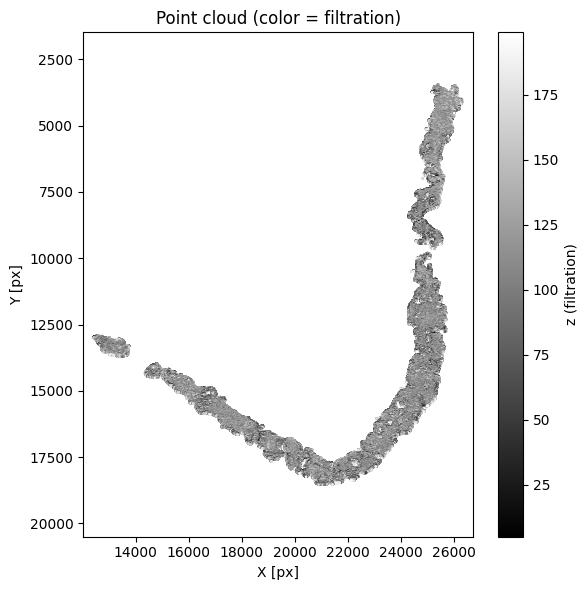

3) Propagate filtr.:  33%|███▎      | 2/6 [00:14<00:24,  6.06s/it]<ipython-input-16-34590865584e>:77: DeprecationWarning: Since Gudhi 3.2, calling SimplexTree.initialize_filtration is unnecessary.
  st.initialize_filtration()
5) Plot diagram:  67%|██████▋   | 4/6 [00:56<00:29, 14.87s/it]       

[INFO] Showing 89763 points with distance ≥ 10.0 from diagonal


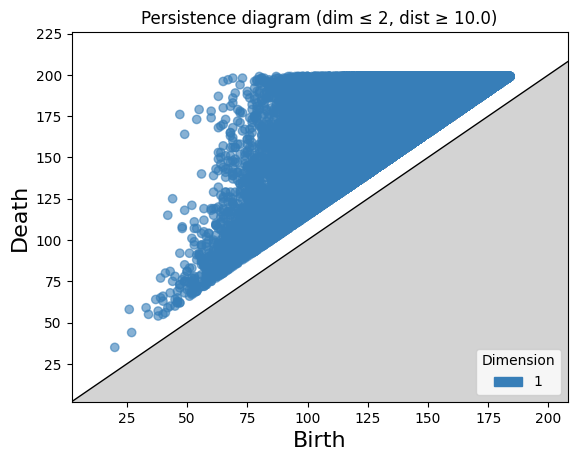

6) Save result: 100%|██████████| 6/6 [01:00<00:00, 10.03s/it]


[INFO] Persistence diagram saved to: /content/results/4_point_cloud_pers_dim2_dist10.0.txt


In [ ]:
def main():
    parser = argparse.ArgumentParser(
        prog=os.path.basename(sys.argv[0]),
        description="Persistent homology (Delaunay triangulation) with explicit max-over-faces filtration"
    )
    parser.add_argument('infile',
                        help='TXT file with three columns: x y z')
    parser.add_argument('step', type=int, nargs='?', default=1,
                        help='take every STEP-th point (default: 1)')
    parser.add_argument('max_dim', type=int, nargs='?', default=2,
                        help='max homology dimension to compute (0→H₀,1→H₁,2→H₂)')
    parser.add_argument('-k', '--min_dist', type=float, default=0.0,
                        help='minimum distance from diagonal (in birth-death units) to display on persistence diagram (default: 0)')

    args = parser.parse_args()

    if not os.path.isfile(args.infile):
        print(f"Error: file not found: {args.infile}", file=sys.stderr)
        sys.exit(1)

    # 1) Load & sample
    data = np.loadtxt(args.infile)
    if data.ndim != 2 or data.shape[1] != 3:
        print("Error: input must have 3 columns: x y z", file=sys.stderr)
        sys.exit(1)
    pts = data[:, :2]
    filtr = data[:, 2]
    N = len(pts)
    if args.step > 1:
        idx = np.arange(0, N, args.step)
        pts = pts[idx]
        filtr = filtr[idx]
    print(f"[INFO] Loaded {N} points, sampled step={args.step} → {len(pts)} points")

    # 2) 2D preview
    plt.figure(figsize=(6, 6))
    sc = plt.scatter(pts[:, 0], pts[:, 1], c=filtr,
                     cmap='gray', s=2, marker='.')
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.xlabel('X [px]')
    plt.ylabel('Y [px]')
    plt.title('Point cloud (color = filtration)')
    plt.colorbar(sc, label='z (filtration)')
    plt.tight_layout()
    plt.show()

    # 3) Delaunay triangulation → filtracja → persystencja → zapis
    stages = ["build", "vertex-filtr.", "propagate", "compute", "plot", "save"]
    with tqdm(total=len(stages), desc="Overall") as pbar:
        # 3.1) Build Delaunay triangulation
        pbar.set_description("1) Build triangulation")
        dc = gudhi.DelaunayComplex(points=pts)
        st = dc.create_simplex_tree()
        pbar.update(1)

        # 3.2) Assign vertex filtrations
        pbar.set_description("2) Vertex-filtr.")
        for vidx, z in enumerate(filtr):
            st.assign_filtration([vidx], z)
        pbar.update(1)

        # 3.3) Propagate filtration: max over faces
        pbar.set_description("3) Propagate filtr.")
        max_dim_tree = st.dimension()
        for dim in range(1, max_dim_tree + 1):
            # iterate only simplices of exact dimension 'dim'
            for simplex, _ in st.get_skeleton(dim):
                if len(simplex) != dim + 1:
                    continue
                # compute max filtration among all (dim-1)-faces
                face_filtrs = [st.filtration(list(face))
                               for face in itertools.combinations(simplex, dim)]
                # assign the maximum of face filtrations
                st.assign_filtration(simplex, max(face_filtrs))
        # reorder internal filtration values
        st.initialize_filtration()
        pbar.update(1)

        # 3.4) Compute persistence
        pbar.set_description("4) Compute persistence")
        raw_pers = st.persistence()
        pbar.update(1)

        # 3.5) Filter by dimension and distance threshold, then plot
        pbar.set_description("5) Plot diagram")
        pers = [(dim, (b, d)) for dim, (b, d) in raw_pers if dim == 1]
        thresh = args.min_dist
        filtered = [(dim, (b, d)) for dim, (b, d) in pers
                    if abs(d - b) / np.sqrt(2) >= thresh]
        if thresh > 0:
            print(f"[INFO] Showing {len(filtered)} points with distance ≥ {thresh} from diagonal")
        gudhi.plot_persistence_diagram(filtered)
        plt.title(f'Persistence diagram (dim ≤ {args.max_dim}, dist ≥ {thresh})')
        plt.show()
        pbar.update(1)

        # 3.6) Save result
        pbar.set_description("6) Save result")
        out = os.path.splitext(args.infile)[0] + f'_pers_dim{args.max_dim}_dist{thresh}.txt'
        with open(out, 'w') as f:
            f.write("# dim birth death\n")
            for dim, (b, d) in filtered:
                f.write(f"{dim} {b:.6f} {d:.6f}\n")
        pbar.update(1)

    print(f"[INFO] Persistence diagram saved to: {out}")


if __name__ == "__main__":
    main()

#Liczenie odległości między diagramami

In [ ]:
import sys
sys.argv = [
    'colab_kernel_launcher.py',
    '/content/results/0_point_cloud_pers_dim2_dist10.0.txt',
    '/content/results/1_point_cloud_pers_dim2_dist10.0.txt',
    '/content/results/2_point_cloud_pers_dim2_dist10.0.txt',
    '/content/results/3_point_cloud_pers_dim2_dist10.0.txt',
    '/content/results/4_point_cloud_pers_dim2_dist10.0.txt',
    '/content/results/5_point_cloud_pers_dim2_dist10.0.txt',
    '--b', '/content/results/0_point_cloud_pers_dim2_dist10.txt',
    '--d', '1'
]

In [ ]:
#!/usr/bin/env python3
import sys
import os
import argparse

import gudhi
import numpy as np

def read_diagram(filename, dim):
    """
    Wczytuje diagram persystencji z pliku tekstowego,
    zwraca listę (birth, death) dla podanego wymiaru dim.
    """
    pairs = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) != 3:
                continue
            d, b, de = parts
            try:
                d = int(d)
                b = float(b)
                de = float(de)
            except ValueError:
                continue
            if d == dim:
                pairs.append((b, de))
    return pairs


def main():
    parser = argparse.ArgumentParser(
        prog=os.path.basename(sys.argv[0]),
        description="Znajdź diagram z A najbliższy diagramowi B w wymiarze d"
    )
    parser.add_argument('a_files', nargs='+',
                        help='Lista plików diagramów A')
    parser.add_argument('-b', '--b_file', required=True,
                        help='Plik diagramu B')
    parser.add_argument('-d', '--dim', type=int, required=True,
                        help='Wymiar homologiczy do porównania')
    args = parser.parse_args()
    # katalog skryptu jako baza dla ścieżek względnych
    script_dir = os.getcwd()

    # Sprawdzenie pliku B
    if not os.path.isfile(args.b_file):
        print(f"Error: B-file not found: {args.b_file}", file=sys.stderr)
        sys.exit(1)

    # Wczytaj diagram B
    diag_b = read_diagram(args.b_file, args.dim)
    if not diag_b:
        print(f"Warning: Brak punktów w wymiarze {args.dim} w pliku B", file=sys.stderr)

    best_file = None
    best_dist = None

    for orig in args.a_files:
        a = orig
        # jeśli ścieżka nie istnieje, spróbuj wobec katalogu skryptu
        if not os.path.isfile(a):
            candidate = os.path.join(script_dir, a)
            if os.path.isfile(candidate):
                a = candidate
            else:
                print(f'Warning: A-file not found: {orig}', file=sys.stderr)
                continue
        # Pomijamy plik B, jeśli występuje w A
        try:
            if os.path.samefile(a, args.b_file):
                print(f"[INFO] Pomijanie pliku B w zestawie A: {a}")
                continue
        except Exception:
            pass

        if not os.path.isfile(a):
            print(f"Warning: A-file not found: {a}", file=sys.stderr)
            continue

        diag_a = read_diagram(a, args.dim)
        if not diag_a:
            print(f"Warning: Brak punktów w wymiarze {args.dim} w pliku A: {a}", file=sys.stderr)
            continue

        try:
            dist = gudhi.bottleneck_distance(diag_a, diag_b)
        except Exception as e:
            print(f"Error computing distance for {a}: {e}", file=sys.stderr)
            continue

        print(f"Distance({os.path.basename(a)}, {os.path.basename(args.b_file)}) = {dist:.6f}")
        if best_dist is None or dist < best_dist:
            best_dist = dist
            best_file = a

    if best_file is None:
        print("Nie znaleziono żadnego porównywalnego diagramu z zestawu A.")
        sys.exit(1)

    print(f"\nNajbliższy diagram do {args.b_file} to : {best_file} (distance = {best_dist:.6f})")

if __name__ == "__main__":
    main()


[INFO] Pomijanie pliku B w zestawie A: /content/results/0_point_cloud_pers_dim2_dist3.0.txt
